#### 30-day mortality: one model, four fits

Target `mortality_30_days` (Bernoulli 0/1) — 49 deaths of 400 (12.2%).

The three never-missing features can be modelled straight away. The question is what
happens when you add one that **is** missing, and whether it depends on *how* it went
missing.

| fit | features | n rows |
|---|---|---|
| **A** | age, gender, chief_complaint | 400 |
| **B** | A + `saturation_mcar` + `sat_missing` | 400 |
| **C** | A + `saturation_mar` + `sat_missing` | 400 |
| **D** | A + `saturation_mnar` + `sat_missing` | 400 |

Identical encoding, identical priors, n=400 in every fit. The only thing that varies
is the mechanism, so any difference is caused by the missingness rather than the code.

In `my-env`: pandas, numpy, pymc, pytensor.tensor  arviz, patsy, scikit-learn, seaborn, matplotlib.

Low saturation is the dominant driver in this cohort, and the gradient is steep
at the severe end:

| saturation band | deaths | n | mortality |
|---|---|---|---|
| 84–89 | 16 | 38 | **42.1%** |
| 90–92 | 6 | 41 | 14.6% |
| 93–95 | 16 | 98 | 16.3% |
| 96–100 | 11 | 222 | 5.0% |

**SpO₂ 84–89 carries 42.1% mortality (16/38) against 9.1% above 90** — roughly
4.6×. This is the effect size the MNAR mechanism selects on, and it is why losing
readings in the hypoxaemic tail matters. Treat the severe band with caution: 38
patients is a small denominator, and the simulated relationship is deliberately
stronger than a typical real cohort.

In [ ]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
import numpy as np
import pandas as pd
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt


# Load the synthetic healthcare dataset with explicit missingness scenarios.
# We will use the age, gender, complaint pattern and the saturation variable
# to model 30-day mortality under different missingness mechanisms.
base_df = pd.read_csv('healthcare_dataset_2_missingness.csv')

# Standardize age once so the coefficients are on a comparable scale.
age_scaled = (base_df['age'] - base_df['age'].mean()) / base_df['age'].std()

# Convert gender to binary (1 = Female, 0 = Male). This keeps the feature matrix
# compatible with a Bernoulli regression and makes the coefficient interpretation straightforward.
is_female = (base_df['gender'] == 'Female').astype(int)

# One-hot encode chief complaints (dropping one to avoid multicollinearity)
# WHY? Because if we include all categories, the model will have perfect multicollinearity
# (the sum of all dummy variables equals 1), which can cause issues in regression models.

# By dropping one category, we avoid this problem and allow the model to estimate the effect

# of each category relative to the dropped category.
complaints = pd.get_dummies(base_df['chief_complaint'], drop_first=True, dtype=int)

In [ ]:
def mice_imputation(df):
    
    # This function is a lightweight wrapper around iterative imputation.
    # It keeps the missing value pattern in the data while using a Bayesian linear
    # model at each step to draw a plausible value for each missing cell.
    df = pd.DataFrame()

    # BayesianRidge matches the standard stochastic chained-equation formulation:
    # each variable is regressed on the others, missing values are updated iteratively,
    # and the model draws from the posterior rather than using a single deterministic fill.
    mice_imputer = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=10,        # Number of chained cycles for stability and convergence
        random_state=42,
        sample_posterior=True  # Draws from posterior to account for imputation uncertainty
    )

    # Fit on the observed data and replace the missing cells with the imputed values.
    imputed_array = mice_imputer.fit_transform(df)
    df_mice = pd.DataFrame(imputed_array, columns=df.columns)

    print("MICE Imputed Data:")
    print(df_mice.round(1))

In [ ]:
def em_impute_mvn(X, max_iter=100, tol=1e-4):
    """
    Expectation-Maximization imputation under a Multivariate Normal assumption.
    X: 2D numpy array with np.nan for missing values.
    """
    # Work on a copy so we can iteratively fill missing values without changing the original input.
    X = X.copy()
    n, p = X.shape
    nan_mask = np.isnan(X)

    # Start from column means so the EM loop has a valid initial complete dataset.
    col_means = np.nanmean(X, axis=0)
    for j in range(p):
        X[nan_mask[:, j], j] = col_means[j]

    # Initial Gaussian estimates: mean vector and covariance matrix.
    mu = np.mean(X, axis=0)
    sigma = np.cov(X, rowvar=False) + np.eye(p) * 1e-6

    for iteration in range(max_iter):
        mu_old = mu.copy()

        # These accumulate the expected sufficient statistics under the current Gaussian model.
        sum_x = np.zeros(p)
        sum_xx = np.zeros((p, p))

        # E-step: for each row, estimate its missing entries conditional on the observed entries.
        for i in range(n):
            obs = ~nan_mask[i]
            mis = nan_mask[i]

            if not np.any(mis):
                # Completely observed row: contributions are exact and no conditional expectation is needed.
                x_i = X[i, :]
                sum_x += x_i
                sum_xx += np.outer(x_i, x_i)
            else:
                # Split parameters into observed and missing coordinates.
                mu_obs = mu[obs]
                mu_mis = mu[mis]
                sigma_obs_obs = sigma[np.ix_(obs, obs)]
                sigma_mis_obs = sigma[np.ix_(mis, obs)]
                sigma_mis_mis = sigma[np.ix_(mis, mis)]

                # Invert observed covariance to compute the conditional Gaussian mean.
                inv_sigma_obs = np.linalg.pinv(sigma_obs_obs)

                # Conditional expectation E[X_mis | X_obs].
                x_obs = X[i, obs]
                cond_mean = mu_mis + sigma_mis_obs @ inv_sigma_obs @ (x_obs - mu_obs)

                # Conditional covariance Var[X_mis | X_obs].
                cond_cov = sigma_mis_mis - sigma_mis_obs @ inv_sigma_obs @ sigma_mis_obs.T

                # Assemble the full expected row for the sufficient statistics.
                x_full = np.empty(p)
                x_full[obs] = x_obs
                x_full[mis] = cond_mean

                # Update expected sufficient statistics; the conditional covariance is added
                # to the missing-by-missing block because the imputed values are uncertain.
                sum_x += x_full
                outer_xx = np.outer(x_full, x_full)
                outer_xx[np.ix_(mis, mis)] += cond_cov
                sum_xx += outer_xx

                # Replace the missing entries with their conditional means.
                X[i, mis] = cond_mean

        # M-step: re-estimate the Gaussian parameters from the completed data.
        mu = sum_x / n
        sigma = (sum_xx / n) - np.outer(mu, mu)
        sigma = (sigma + sigma.T) / 2 + np.eye(p) * 1e-6  # Ensure symmetry & numerical stability.

        # Stop once the mean estimates stop moving materially.
        if np.max(np.abs(mu - mu_old)) < tol:

            break    return X


In [ ]:


def sample_missingness_model(sat_column_name):
    
    # Missingness indicator: 1 means the saturation value was missing for that patient.
    # This lets the model ask whether the probability of death changes when the missingness pattern itself is informative.
    is_missing = base_df[sat_column_name].isna().astype(int).values
    sat_masked = np.ma.masked_invalid(base_df[sat_column_name].values)

    with pm.Model() as model:
        # Standard priors for the Bernoulli mortality model. These keep the coefficients
        # regularized while allowing the data to drive the magnitude of the effects.
        intercept = pm.Normal('intercept', mu=0, sigma=1.5)
        w_age = pm.Normal('w_age', mu=0, sigma=1)
        w_female = pm.Normal('w_female', mu=0, sigma=1)
        w_sat = pm.Normal('w_sat', mu=0, sigma=1)
        w_complaints = pm.Normal('w_complaints', mu=0, sigma=1, shape=complaints.shape[1])

        # Missingness effect: if the mechanism carries information about mortality,
        # this coefficient should move away from zero.
        w_missing = pm.Normal('w_missing', mu=0, sigma=1)

        # Treat the saturation value as latent for missing rows and observed for present rows.
        # The masked values are inferred jointly with the mortality outcome.
        sat_imputed = pm.Normal('sat_imputed', mu=95, sigma=3, observed=sat_masked)
        sat_scaled = (sat_imputed - 95) / 3

        # The mortality risk uses the observed or imputed saturation plus the missingness flag.
        # This is the key part of the missingness-aware model: it does not only model the value,
        # it also models whether the value was missing.
        log_odds = (intercept +
                    w_age * age_scaled +
                    w_female * is_female +
                    w_sat * sat_scaled +
                    w_missing * is_missing +
                    pm.math.dot(complaints.values, w_complaints))

        p_mortality = pm.Deterministic('p_mortality', pm.math.sigmoid(log_odds))

        likelihood = pm.Bernoulli('likelihood', logit_p=log_odds, observed=base_df['mortality_30_days'])

        # Draw posterior samples; this gives us a distribution over coefficients and risk predictions.
        trace = pm.sample(draws=2000, tune=1000, target_accept=0.9, progressbar=False)

        # Compute log-likelihood for model diagnostics and possible comparisons.
        pm.compute_log_likelihood(trace)

    return trace

# Run the function for all three missingness mechanisms.

# This gives a posterior sample for each scenario: MCAR, MAR, and MNAR.trace_mnar = traces['saturation_mnar']

traces = {}

for pattern in ['saturation_mcar', 'saturation_mar', 'saturation_mnar']:
    print(f"Sampling {pattern}...")
    traces[pattern] = sample_missingness_model(pattern)

trace_mnar = traces['saturation_mnar']




/opt/anaconda3/envs/my-env/lib/python3.12/site-packages/pymc/model/core.py:2061: ImputationWarning: Data in sat_imputed contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Initializing NUTS using jitter+adapt_diag...


Sampling saturation_mcar...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, w_age, w_female, w_sat, w_complaints, w_missing, sat_imputed_unobserved]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 12 seconds.


/opt/anaconda3/envs/my-env/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/opt/anaconda3/envs/my-env/lib/python3.12/site-packages/pymc/model/core.py:2061: ImputationWarning: Data in sat_imputed contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Initializing NUTS using jitter+adapt_diag...


...

/opt/anaconda3/envs/my-env/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/opt/anaconda3/envs/my-env/lib/python3.12/site-packages/pymc/model/core.py:2061: ImputationWarning: Data in sat_imputed contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Initializing NUTS using jitter+adapt_diag...


Sampling saturation_mnar...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, w_age, w_female, w_sat, w_complaints, w_missing, sat_imputed_unobserved]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 11 seconds.


/opt/anaconda3/envs/my-env/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [81]:
# Extract the predicted probabilities from the trace
trace_mar = traces['saturation_mar']
trace_mnar = traces['saturation_mnar']
trace_mcar = traces['saturation_mcar']


# Average the probabilities across all MCMC draws for each patient
predicted_probs = trace_mcar.posterior['p_mortality'].mean(dim=["chain", "draw"]).values

# 2. Put the true target and the model's prediction side-by-side
results_df = pd.DataFrame({
    'Patient_ID': base_df.index,
    'True_Mortality': base_df['mortality_30_days'],  
    'Predicted_Prob': predicted_probs                
})

# Display the first 15 patients
print(results_df.head(15))

    Patient_ID  True_Mortality  Predicted_Prob
0            0               0        0.088537
1            1               1        0.506473
2            2               1        0.148859
3            3               0        0.192929
4            4               0        0.036015
5            5               0        0.140665
6            6               0        0.013464
7            7               0        0.231734
8            8               0        0.082461
9            9               0        0.032877
10          10               0        0.020157
11          11               0        0.253480
12          12               0        0.032784
13          13               0        0.146124
14          14               0        0.157459


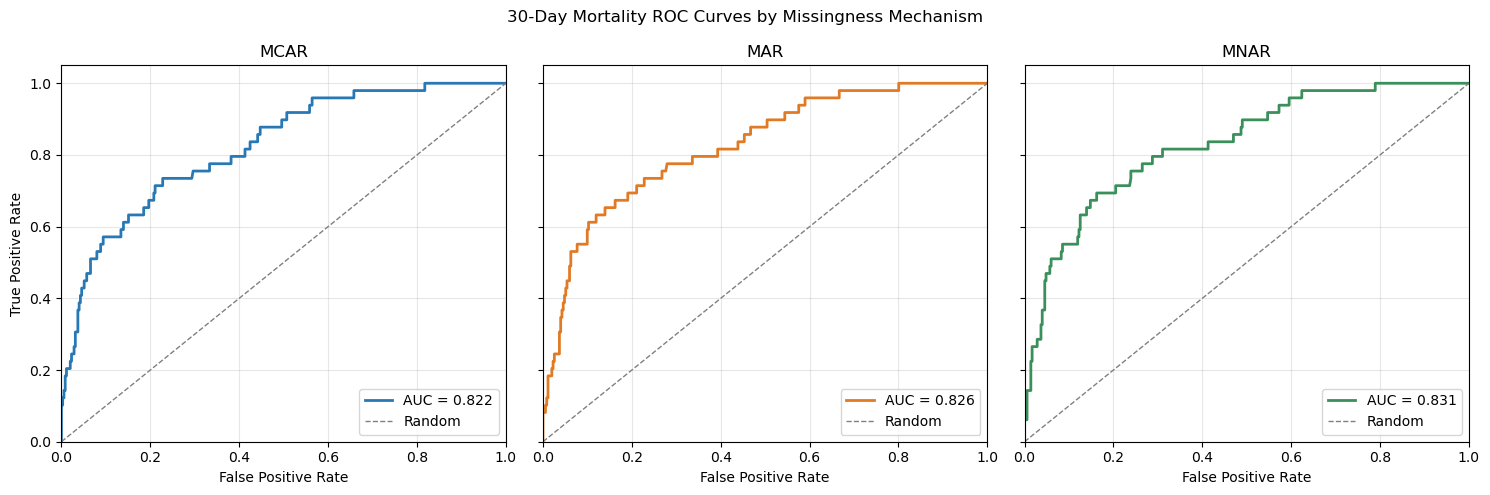

ROC-AUC comparison:
MNAR   0.831
MAR    0.826
MCAR   0.822


In [82]:


true_mortality = base_df["mortality_30_days"].to_numpy()
model_names = ["saturation_mcar", "saturation_mar", "saturation_mnar"]
model_titles = ["MCAR", "MAR", "MNAR"]
colors = ["#2878B5", "#E07A25", "#3A8F5B"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
auc_scores = {}

for ax, name, title, color in zip(axes, model_names, model_titles, colors):
    predicted_probs = (
        traces[name].posterior["p_mortality"]
        .mean(dim=["chain", "draw"])
        .values
    )
    auc = roc_auc_score(true_mortality, predicted_probs)
    fpr, tpr, _ = roc_curve(true_mortality, predicted_probs)
    auc_scores[title] = auc

    ax.plot(fpr, tpr, color=color, lw=2, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right")

axes[0].set_ylabel("True Positive Rate")
fig.suptitle("30-Day Mortality ROC Curves by Missingness Mechanism")
fig.tight_layout()
plt.show()

auc_comparison = pd.Series(auc_scores, name="ROC-AUC").sort_values(ascending=False)
print("ROC-AUC comparison:")
print(auc_comparison.to_string(float_format=lambda score: f"{score:.3f}"))


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, w_age, w_female, w_sat, w_complaints]
Sampling 2 chains for 400 tune and 800 draw iterations (800 + 1_600 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, w_age, w_female, w_sat, w_complaints]
Sampling 2 chains for 400 tune and 800 draw iterations (800 + 1_600 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, w_age, w_female, w_sat, w_complaints]
Sampling 2 chains for 400 tune and 800 draw iterations (800 + 1_600 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS u

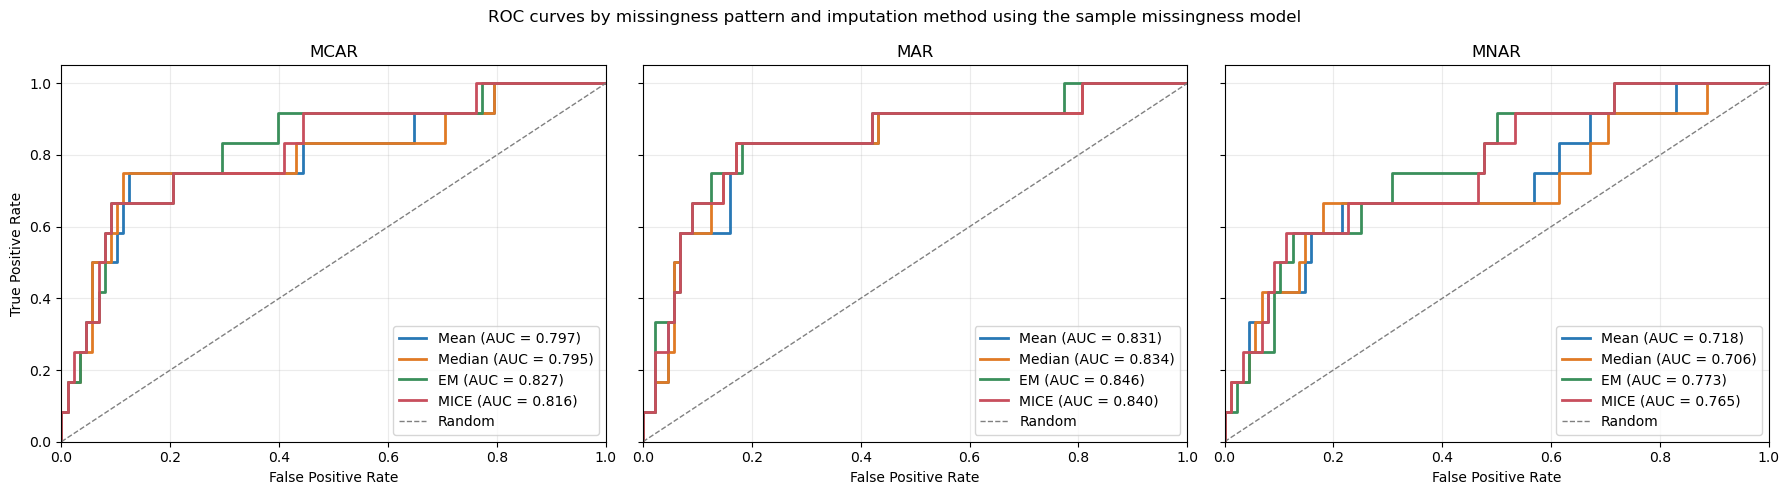

AUC by missingness pattern and imputation method:
Imputation      EM   MICE   Mean  Median
Missingness                             
MAR          0.846  0.840  0.831   0.834
MCAR         0.827  0.816  0.797   0.795
MNAR         0.773  0.765  0.718   0.706


In [ ]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.model_selection import train_test_split
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import roc_auc_score, roc_curve

# Use the notebook's Bayesian missingness model instead of a scikit-learn logistic regression.
# The comparison still stays by missingness pattern and imputation strategy, but the fitted model
# is the same PyMC structure already used elsewhere in this notebook.
df = pd.read_csv('healthcare_dataset_2_missingness.csv').copy()
df['gender'] = (df['gender'] == 'Female').astype(int)

missingness_patterns = {
    'MCAR': 'saturation_mcar',
    'MAR': 'saturation_mar',
    'MNAR': 'saturation_mnar',
}

# Existing notebook imputers / imputation patterns

def mean_impute(train_df, test_df):
    sat_col = train_df.columns[train_df.isna().any()][0]
    fill_value = train_df[sat_col].mean()
    return train_df.fillna({sat_col: fill_value}), test_df.fillna({sat_col: fill_value})


def median_impute(train_df, test_df):
    sat_col = train_df.columns[train_df.isna().any()][0]
    fill_value = train_df[sat_col].median()
    return train_df.fillna({sat_col: fill_value}), test_df.fillna({sat_col: fill_value})


def em_impute(train_df, test_df):
    train_arr = train_df.to_numpy(dtype=float).copy()
    test_arr = test_df.to_numpy(dtype=float).copy()
    train_imputed = pd.DataFrame(em_impute_mvn(train_arr), columns=train_df.columns)
    test_imputed = pd.DataFrame(em_impute_mvn(test_arr), columns=test_df.columns)
    return train_imputed, test_imputed


# TODO: update to fi
def mice_impute(train_df, test_df):
    imputer = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=20,
        random_state=42,
    )
    train_imp = pd.DataFrame(imputer.fit_transform(train_df), columns=train_df.columns)
    test_imp = pd.DataFrame(imputer.transform(test_df), columns=test_df.columns)
    return train_imp, test_imp


imputation_methods = {
    'Mean': mean_impute,
    'Median': median_impute,
    'EM': em_impute,
    'MICE': mice_impute,
}


def fit_sample_missingness_model(train_df, test_df, target_col='mortality_30_days'):
    """Fit the notebook's Bayesian missingness model to the train set and score the test set."""
    sat_col = [c for c in train_df.columns if 'saturation' in c][0]
    complaint_cols = [c for c in train_df.columns if c.startswith('chief_complaint')]

    # Scale continuous predictors using the training distribution only.
    age_mean = train_df['age'].mean()
    age_std = train_df['age'].std(ddof=0)
    if age_std == 0:
        age_std = 1.0

    sat_mean = train_df[sat_col].mean()
    sat_std = train_df[sat_col].std(ddof=0)
    if sat_std == 0:
        sat_std = 1.0

    X_train = train_df.copy()
    X_test = test_df.copy()
    y_train = X_train.pop(target_col).to_numpy()
    y_test = X_test.pop(target_col).to_numpy()

    X_train['age'] = (X_train['age'] - age_mean) / age_std
    X_test['age'] = (X_test['age'] - age_mean) / age_std
    X_train[sat_col] = (X_train[sat_col] - sat_mean) / sat_std
    X_test[sat_col] = (X_test[sat_col] - sat_mean) / sat_std

    age_train = X_train['age'].to_numpy()
    age_test = X_test['age'].to_numpy()
    female_train = X_train['gender'].to_numpy()
    female_test = X_test['gender'].to_numpy()
    sat_train = X_train[sat_col].to_numpy()
    sat_test = X_test[sat_col].to_numpy()
    complaint_train = X_train[complaint_cols].to_numpy()
    complaint_test = X_test[complaint_cols].to_numpy()

    with pm.Model() as model:
        intercept = pm.Normal('intercept', mu=0, sigma=1.5)
        w_age = pm.Normal('w_age', mu=0, sigma=1)
        w_female = pm.Normal('w_female', mu=0, sigma=1)
        w_sat = pm.Normal('w_sat', mu=0, sigma=1)
        w_complaints = pm.Normal('w_complaints', mu=0, sigma=1, shape=complaint_train.shape[1])

        log_odds = (
            intercept
            + w_age * age_train
            + w_female * female_train
            + w_sat * sat_train
            + pm.math.dot(complaint_train, w_complaints)
        )

        pm.Bernoulli('likelihood', logit_p=log_odds, observed=y_train)

        trace = pm.sample(
            draws=800,
            tune=400,
            chains=2,
            cores=1,
            target_accept=0.9,
            progressbar=False,
        )

    alpha = trace.posterior['intercept'].values.reshape(-1)
    beta_age = trace.posterior['w_age'].values.reshape(-1)
    beta_female = trace.posterior['w_female'].values.reshape(-1)
    beta_sat = trace.posterior['w_sat'].values.reshape(-1)
    beta_complaints = trace.posterior['w_complaints'].values.reshape(-1, complaint_train.shape[1])

    lin_test = (
        alpha[:, None]
        + beta_age[:, None] * age_test[None, :]
        + beta_female[:, None] * female_test[None, :]
        + beta_sat[:, None] * sat_test[None, :]
        + beta_complaints @ complaint_test.T
    )
    test_probs = 1 / (1 + np.exp(-lin_test)).mean(axis=0)
    return test_probs, y_test


results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = ['#2878B5', '#E07A25', '#3A8F5B', '#C84E5D']

# Benchmark loop across the three missingness patterns.
# For each pattern we keep the same train/test split, apply each imputation strategy,
# fit the sample missingness model and then compare AUC values across methods.
for ax, (pattern_name, sat_column) in zip(axes, missingness_patterns.items()):
    # Select the relevant saturation column for this mechanism and one-hot encode the complaint variable.
    pattern_df = df[['age', 'gender', 'chief_complaint', sat_column, 'mortality_30_days']].copy()
    pattern_df = pd.get_dummies(pattern_df, columns=['chief_complaint'], drop_first=True, dtype=float)

    # Separate features (X) from the binary target (y).
    X = pattern_df.drop(columns='mortality_30_days')
    y = pattern_df['mortality_30_days']

    # Split once per pattern for a fair comparison. We stratify on the outcome so the train
    # and test sets preserve the original mortality rate.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y,
    )

    # Reattach the target to the train/test frames so the imputer and model both see the target
    # in the same structure when they fit the sample missingness model.
    X_train = pd.concat([X_train, y_train], axis=1)
    X_test = pd.concat([X_test, y_test], axis=1)

    # Try each imputation method and score the same model on the resulting completed data.
    for method_name, method in imputation_methods.items():
        X_train_imp, X_test_imp = method(X_train.copy(), X_test.copy())
        test_probs, test_y = fit_sample_missingness_model(X_train_imp, X_test_imp)
        auc = roc_auc_score(test_y, test_probs)
        fpr, tpr, _ = roc_curve(test_y, test_probs)

        # Store one row per missingness pattern + imputation method so we can compare AUCs cleanly.
        results.append({
            'Missingness': pattern_name,
            'Imputation': method_name,
            'AUC': auc,
        })

        # Use a fixed color for each method so the ROC lines are readable across the three panels.
        color = colors[list(imputation_methods).index(method_name)]
        ax.plot(fpr, tpr, lw=2, color=color, label=f'{method_name} (AUC = {auc:.3f})')

    # Add the random classifier baseline as a reference line.
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Random')
    ax.set_title(pattern_name)
    ax.set_xlabel('False Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25)
    ax.legend(loc='lower right')

axes[0].set_ylabel('True Positive Rate')
fig.suptitle('ROC curves by missingness pattern and imputation method using the sample missingness model')
fig.tight_layout()
plt.show()

# Pivot the results to a table with missingness patterns as rows and imputation method as columns.
summary_df = pd.DataFrame(results).pivot_table(index='Missingness', columns='Imputation', values='AUC')
print('AUC by missingness pattern and imputation method:')
print(summary_df.round(3).to_string())

In [ ]:
# Compare the AUCs from the sample missingness-model benchmark.
# This uses the train/test results stored in `results` rather than the older `az.compare(traces, ...)` flow.
if 'results' in locals():
    comparison_df = pd.DataFrame(results).pivot_table(
        index='Missingness',
        columns='Imputation',
        values='AUC',
    )

    print("\nAUC comparison (sample missingness model):")
    print(comparison_df.round(3).to_string())

    print("\nBest imputation method by missingness pattern:")
    print(comparison_df.idxmax(axis=1).to_string())
else:
    print("No benchmark results found in the current notebook state.")


Model Comparison (Powered by Log-Likelihood):
                 rank   elpd  weight
saturation_mar      0 -130.0    0.48
saturation_mcar     1 -130.0    0.43
saturation_mnar     2 -130.0    0.09


## Mathematical specification of the PyMC model

For patient $i$, let $y_i$ be 30-day mortality, $a_i$ standardized age, $f_i$ the female indicator, $m_i$ indicate missing saturation, and $c_i$ the vector of dropped-reference complaint indicators. Let $s_i$ be the latent or observed saturation and $z_i=(s_i-95)/3$.

### Priors

The coefficient priors in the code are independent:

$$
\begin{aligned}
\alpha &\sim \mathcal{N}(0, 1.5^2), \\
w_{age}, w_{female}, w_{sat}, w_{missing} &\sim \mathcal{N}(0, 1^2), \\
w_{complaint,j} &\sim \mathcal{N}(0, 1^2), \quad j=1,\ldots,J.
\end{aligned}
$$

The saturation model is:

$$s_i \sim \mathcal{N}(95, 3^2).$$

Observed saturations are fixed at their recorded values. A masked saturation is a latent variable with this prior; in this joint model, its posterior can also be informed by that patient's mortality outcome.

### Mortality likelihood

The linear predictor and probability are:

$$
\eta_i = \alpha + w_{age}a_i + w_{female}f_i + w_{sat}z_i + w_{missing}m_i + c_i^\mathsf{T}w_{complaint},
\qquad
p_i = \operatorname{logistic}(\eta_i) = \frac{1}{1+e^{-\eta_i}}.
$$

Then the likelihood is:

$$
y_i \mid p_i \sim \operatorname{Bernoulli}(p_i),
\qquad
p(\mathbf y\mid\alpha,\mathbf w,\mathbf s,\mathbf X)
=\prod_{i=1}^n p_i^{y_i}(1-p_i)^{1-y_i}.
$$

### Posterior

Writing $\theta=(\alpha,\mathbf w)$ and letting $s_{mis}$ denote the missing saturations, the joint posterior is proportional to likelihood times priors:

$$
p(\theta,s_{mis}\mid\mathbf y,\mathbf X,s_{obs})
\propto
\left[\prod_i p_i^{y_i}(1-p_i)^{1-y_i}\right]
\,p(\alpha)\,p(\mathbf w)\,p(s_{mis}),
$$

where each missing $s_i$ has its $\mathcal{N}(95,3^2)$ prior. PyMC samples from this posterior; it is not a closed-form distribution.

### Posterior predictive

For a new patient with predictors $x_*$ and a known saturation $s_*$, the posterior predictive probability is the average over posterior draws:

$$
P(y_*=1\mid x_*,s_*,\mathcal D)
=\mathbb E_{\theta\mid\mathcal D}[\operatorname{logistic}(\eta_*)]
\approx \frac{1}{S}\sum_{r=1}^{S}\operatorname{logistic}(\eta_*^{(r)}).
$$

A simulated outcome is then $y_*^{(r)}\sim\operatorname{Bernoulli}(p_*^{(r)})$. If the new patient's saturation is missing, its uncertainty must also be integrated over a model for missing saturation, without conditioning on $y_*$.

**Important for this notebook:** `p_mortality` is computed for the training patients in the same joint model whose likelihood contains their observed outcomes. For patients with missing saturation, those latent values are therefore informed by the outcomes being predicted. These are in-sample fitted probabilities, not an honest out-of-sample predictive evaluation.